# 00 - Teste dos dataloaders

Sanity check do carregamento de dados: usa `criar_dataloaders` (de `src/dataset.py`), confirma o shape dos batches/labels e mostra alguns exemplos (imagens normais de treino e imagens de teste, com verde = normal e vermelho = defeito).

In [1]:
import sys
sys.path.append("../src")   # aponta para a pasta src

from dataset import criar_dataloaders

In [2]:
train_loader, test_loader = criar_dataloaders(
    root="../data/mvtec",
    category="bottle"
)

Categoria: bottle
  Treino: 209 imagens normais
  Teste:  83 imagens (63 defeituosas)


In [3]:
# Ver um batch de imagens
imgs, labels, tipos = next(iter(train_loader))

print("Shape das imagens:", imgs.shape)    # deve ser [32, 3, 256, 256]
print("Labels:", labels[:5])               # tensor([0, 0, 0, 0, 0])
print("Tipos:", tipos[:5])                 # ('good', 'good', ...)

Shape das imagens: torch.Size([32, 3, 256, 256])
Labels: tensor([0, 0, 0, 0, 0])
Tipos: ('good', 'good', 'good', 'good', 'good')


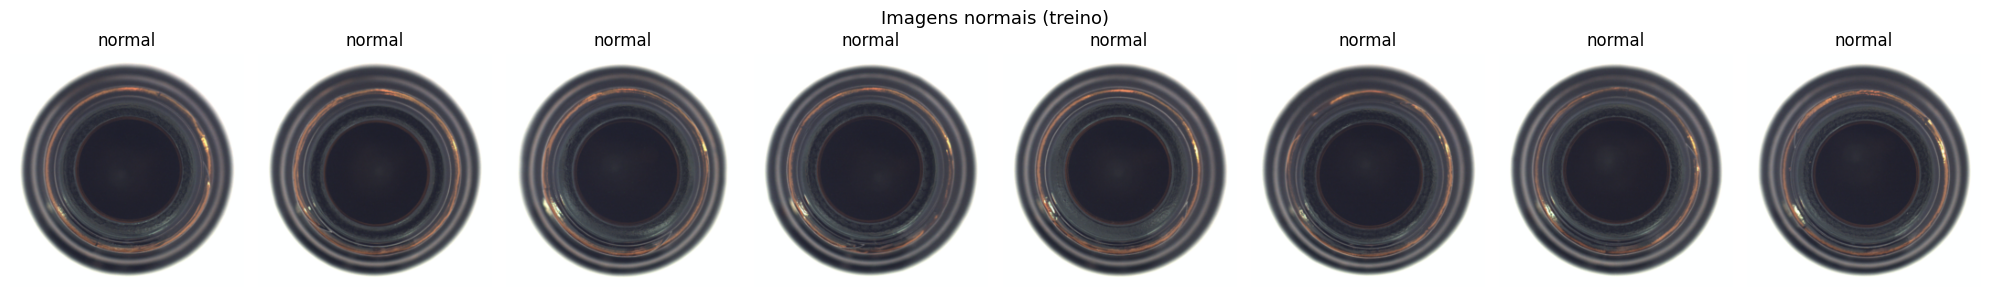

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def desnormalizar(tensor):
    """Desfaz a normalização para conseguir ver a imagem."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()  # [C,H,W] -> [H,W,C]
    img = img * std + mean
    img = np.clip(img, 0, 1)
    return img

# Pega num batch de treino
imgs, labels, tipos = next(iter(train_loader))

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
fig.suptitle("Imagens normais (treino)", fontsize=13)

for i, ax in enumerate(axes):
    ax.imshow(desnormalizar(imgs[i]))
    ax.set_title("normal")
    ax.axis("off")

plt.tight_layout()
plt.show()

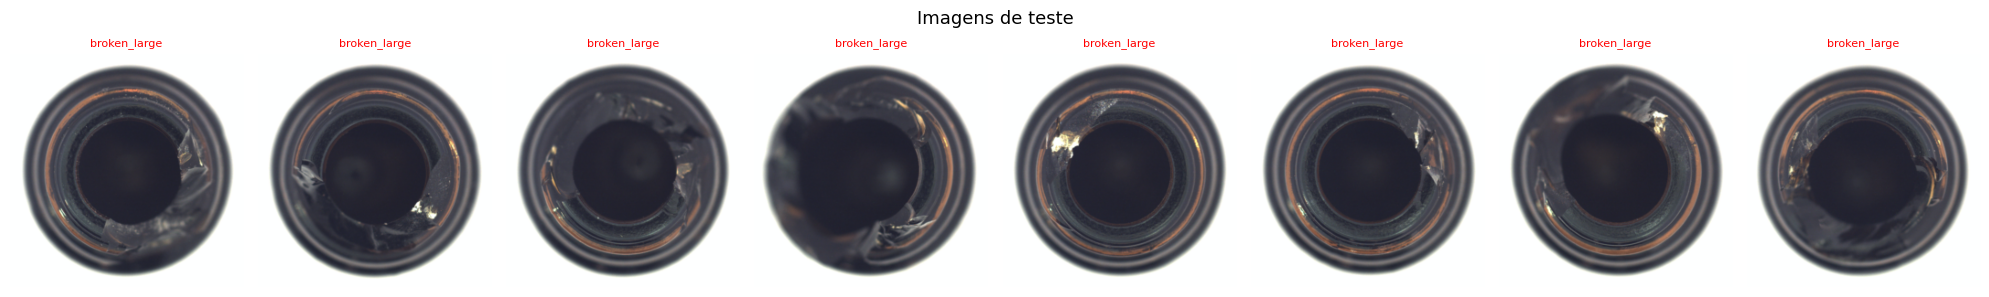

In [5]:
imgs_test, labels_test, tipos_test = next(iter(test_loader))

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
fig.suptitle("Imagens de teste", fontsize=13)

for i, ax in enumerate(axes):
    ax.imshow(desnormalizar(imgs_test[i]))
    cor = "red" if labels_test[i] == 1 else "green"
    ax.set_title(tipos_test[i], color=cor, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()